# Exploratory Data Analysis (EDA)
## Wisconsin Breast Cancer Dataset

---

## Motivating Problem
##### Can we develop a machine learning model that uses cell morphology features to help radiologists differentiate malignant from benign breast masses, thereby reducing unnecessary biopsies without compromising cancer detection rates?

<!-- ### Approach
Our exploration was driven by model considerations and targeted the following questions:
1. What is the prediction problem?
2. What does the data look like?
3. What could break a model?
4. What structure exists in the features?
5. What modelling decisions does this imply? -->

## Notebook Outline
- [Dataset Overview](#1-dataset-overview)
- [Target Variable Analysis](#2-target-variable-analysis)
- [Feature Correlation Analysis](#3-feature-correlation-analysis)
- [Pairwise Feature Relationships](#4-pairwise-feature-relationships)
- [Global Feature Structure](#5-global-feature-structure-pca)
- [Preliminary Feature Importance](#6-preliminary-feature-importance)
- [Proposed Modeling Plan](#8-proposed-modeling-plan)

<!-- _Note: Jupyter Notebook's within-document hyperlinks do not render on GitHub, but will work if running the .ipynb in an IDE such as VS Code_  -->

## 1. Dataset Overview
The [Wisconsin Diagnostic Breast Cancer dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) (WDBC) contains 569 samples (instances) of 30 real-valued input features derived from digitized images of fine needle aspirates (FNAs) of breast masses to predict tumor malignancy. Features describe 10 core characteristics of cell nuclei present in the image, and there are three calculations per feature — mean, standard error, and worst (mean of three largest values).

**Target Variable**: 
- binary classification 
- **classes**: "Malignant" (1) or "Benign" (0)

**Core Feature Definitions**:
- **radius**:           mean of distances from the center to points on the perimeter
- **texture**:          standard deviation of gray-scale values
- **perimeter**:        total length of the boundary
- **area**:             surface area of the nucleus
- **smoothness**:       local variation in radius lengths
- **compactness**:      $\mathrm{(perimeter}^2/\mathrm{area)} - 1.0$
- **concavity**:        severity of concave portions of the contour
- **concave points**:   number of concave portions of the contour
- **symmetry**:         surface symmetry
- **fractal dimension**: "coastline approximation" - 1 

**Key Measures**: mean, standard error, worst

### 1.0 Import Modules
_The src/ folder contains python (.py) scripts needed for running the .ipynb files contained in the notebooks/ (this) folder. The functions in each script help with a certain aspect of the project. At the top of each .ipynb in the notebooks/ folder you will find a code block that sets up access to the src/ folder and its functions. If you remove this code block you will not be able to properly run the notebook._

In [10]:
import sys
from pathlib import Path

# Get repo root (one level above notebooks/)
repo_root = Path().resolve().parent
src_path = repo_root / "src"

# Add src folder to Python path
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

# import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import custom modules (located in src/)
from preprocessing import load_raw_data
import visualization as vis

# settings
sns.set_style(style="white")
print("> Loaded required libraries")
plt.close()

> Loaded required libraries


In [11]:
# hard-coded variables or flags
cols = {"malignant": "darkblue", "benign": "#04b2d1"} # target
measures = ["mean", "error", "worst"]
measures_cols = {"mean": "#3498DB", "error": "#F39C12", "worst": "#E74C3C"} # measures

### 1.1 Load and Inspect the Data
To ensure reproducibility, we have landed the original `wdbc.data` dataset in the `data/raw/` repository folder. The original dataset can also be found on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/) website.

The raw dataset is loaded and cleaned using a helper function. Cleaning steps include standardizing column names and encoding the target variable (malignant = 1, benign = 0). Next, we confirm these data look as expected.

In [12]:
# load dataset
df = load_raw_data("../data/raw/wdbc.data")

# collect column names
feature_names = df.select_dtypes(include = "number").columns.tolist()
target_names = df["diagnosis"].unique().tolist()

# get overview
print(f"Shape of dataset: {df.shape}")
print(f"Target classes ({len(target_names)}): {target_names}")
print(f"Features ({len(feature_names)}): {feature_names}\n")

# check that there are 10 features per measurement
for m in measures:
    count = sum(m in col for col in df.columns)
    print(f"{count} {m} features")

df.head() # snapshot

Shape of dataset: (569, 31)
Target classes (2): ['malignant', 'benign']
Features (30): ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

10 mean features
10 error features
10 worst features


,diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,malignant,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,malignant,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,malignant,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,malignant,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,malignant,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
# print summary of df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   diagnosis                569 non-null    category
 1   mean radius              569 non-null    float64 
 2   mean texture             569 non-null    float64 
 3   mean perimeter           569 non-null    float64 
 4   mean area                569 non-null    float64 
 5   mean smoothness          569 non-null    float64 
 6   mean compactness         569 non-null    float64 
 7   mean concavity           569 non-null    float64 
 8   mean concave points      569 non-null    float64 
 9   mean symmetry            569 non-null    float64 
 10  mean fractal dimension   569 non-null    float64 
 11  radius error             569 non-null    float64 
 12  texture error            569 non-null    float64 
 13  perimeter error          569 non-null    float64 
 14  area error           

#### Observations:
- df is the correct shape (569, 31), with 30 feature columns consisting of real numbers and 1 target column (`diagnosis`) consisting of 2 categorical variables - malignant and benign 
- there are 10 features per measurement, and feature names are labelled according to whether the measurement represents the `mean`, `error`, or `worst` 
- all features are numeric
- lack of any missing values reduces preprocessing complexity

### 1.2 Data Quality & Cleaning
Before conducting any analyses we need to address data quality issues that could impact model quality and/or stability: missing values, duplicates, and zero-variance features.

A visual representation is a quick and helpful way to determine the distribution of missing values across the dataset. If the plot shows structure around a certain feature (column) or set of rows we might suspect missing values not at random. 

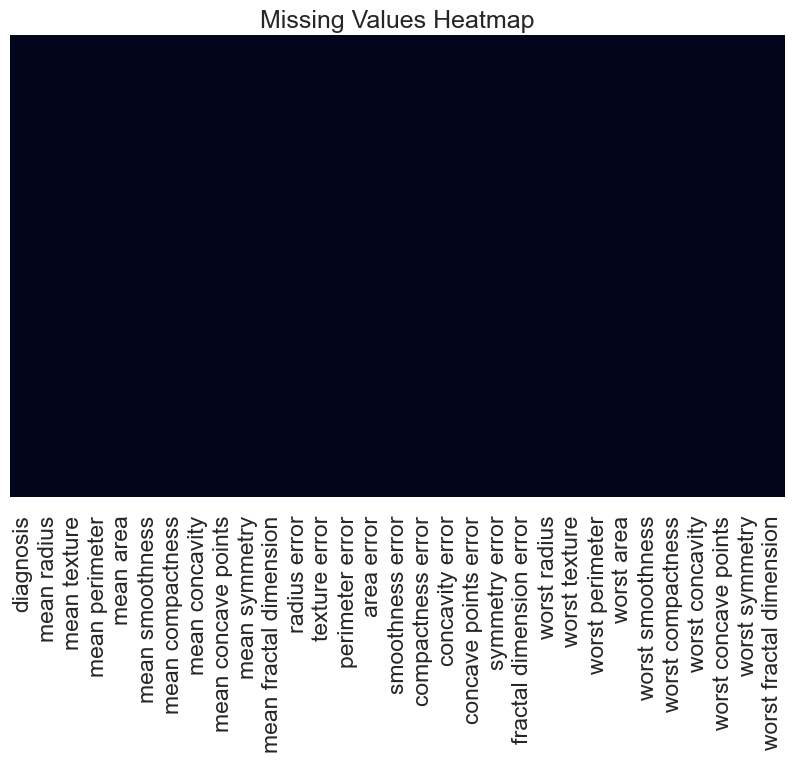

Missing values: 0
Duplicate rows: 0
Zero-variance features: None


['malignant', 'benign']
Categories (2, str): ['malignant', 'benign']

In [14]:
# Visualize missing values
vis.visualize_missing(df)

# check for na, exact row duplicates, constant variance
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
zero_var = [col for col in feature_names if df[col].nunique() == 1]
print(f"Zero-variance features: {zero_var if zero_var else 'None'}")

# ensure class label consistency
df["diagnosis"].unique()

#### Observations:
- No missing values reduces preprocessing complexity - no imputation required.
- No exact row duplicates - each observation only contributes once.
- No zero-variance features found - all features have predictive potential.

### 1.3 Summary Statistics
Although we have not yet considered the influence of outliers, it is still helpful to compute summary statistics on the cleaned data to get a numerical snapshot of each variable:

In [15]:
# Summary statistics
df.describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


## 2. Target Variable Analysis
We examine the distribution of the target classes by obtaining class counts and proportions to determine if reporting model accuracy as our primary metric would be misleading due to class imbalance.

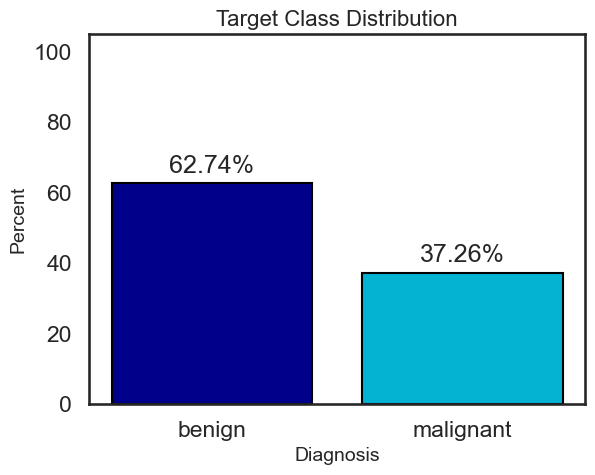

           Count  Percentage (%)
diagnosis                       
benign       357           62.74
malignant    212           37.26


In [16]:
# calculate diagnosis class counts and percentages
counts, pcts = vis.plot_class_distribution(df, column="diagnosis", colors=cols)
print(pd.DataFrame({"Count": counts, "Percentage (%)": pcts.round(2)}))

### Observations:
- the classes are moderately imbalanced (~37% malignant, ~63% benign) 
- **use stratefied splitting for modeling and evaluate with sensitivity/specificity rather than accuracy alone**
- a naive majority classifier would achieve ~63%, so any model must exceed this

## 3. Feature Correlation Analysis
High correlations between features can lead to multicollinearity, which will make certain models (e.g., linear) unstable and potentially misleading. Many of the features are related to geometry, so we can reasonably expect at least some degree of multicollinearity.  

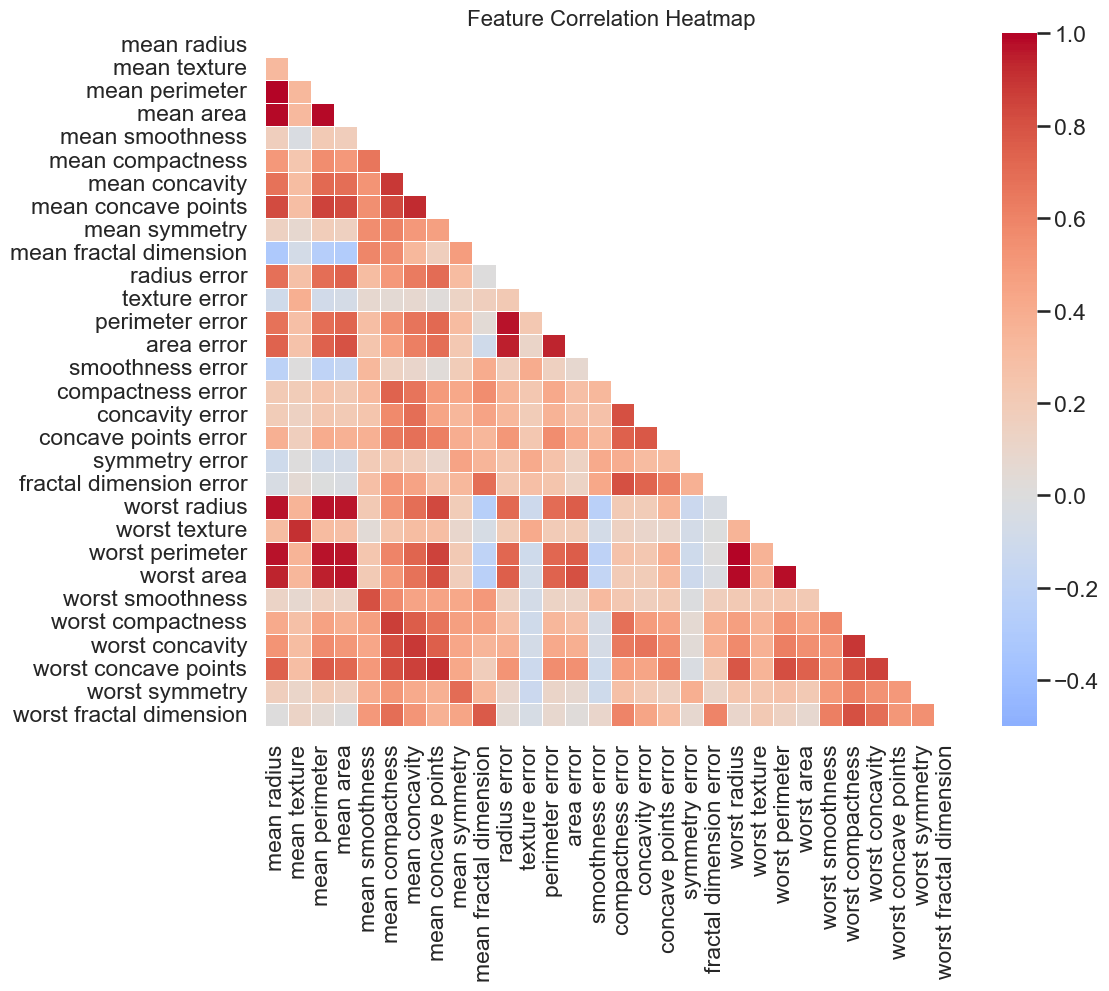

mean radius      mean perimeter    0.997855
worst perimeter  worst radius      0.993708
mean radius      mean area         0.987357
mean perimeter   mean area         0.986507
worst area       worst radius      0.984015
dtype: float64


In [17]:
# plot correlations for all 30 features
corr, high_corr = vis.plot_correlation_heatmap(df)

# get highest correlations
print(high_corr.stack().sort_values(ascending=False).iloc[::2].head(5))

#### Observations:
- multicollinearity is a major concern - many features are highly correlated ($\ge 0.8$)
- radius, perimeter, and area are highly correlated - expected since they measure the same physical property
- high correlation among radius, perimeter, and area may destabilize linear coefficients without regularization
- **use L1 or L2 regularization for logistic regression**
- a tree-based model can handle multicollinearity, but will affect logistic regression coefficients
- **use `StandardScaler()` to handle scale differences**

## 4. Pairwise Feature Relationships
Pairplots help us quickly visualize pairwise relationships and distributions among multiple variables, helping identify patterns, correlations, and potential class separations.

<Figure size 800x600 with 0 Axes>

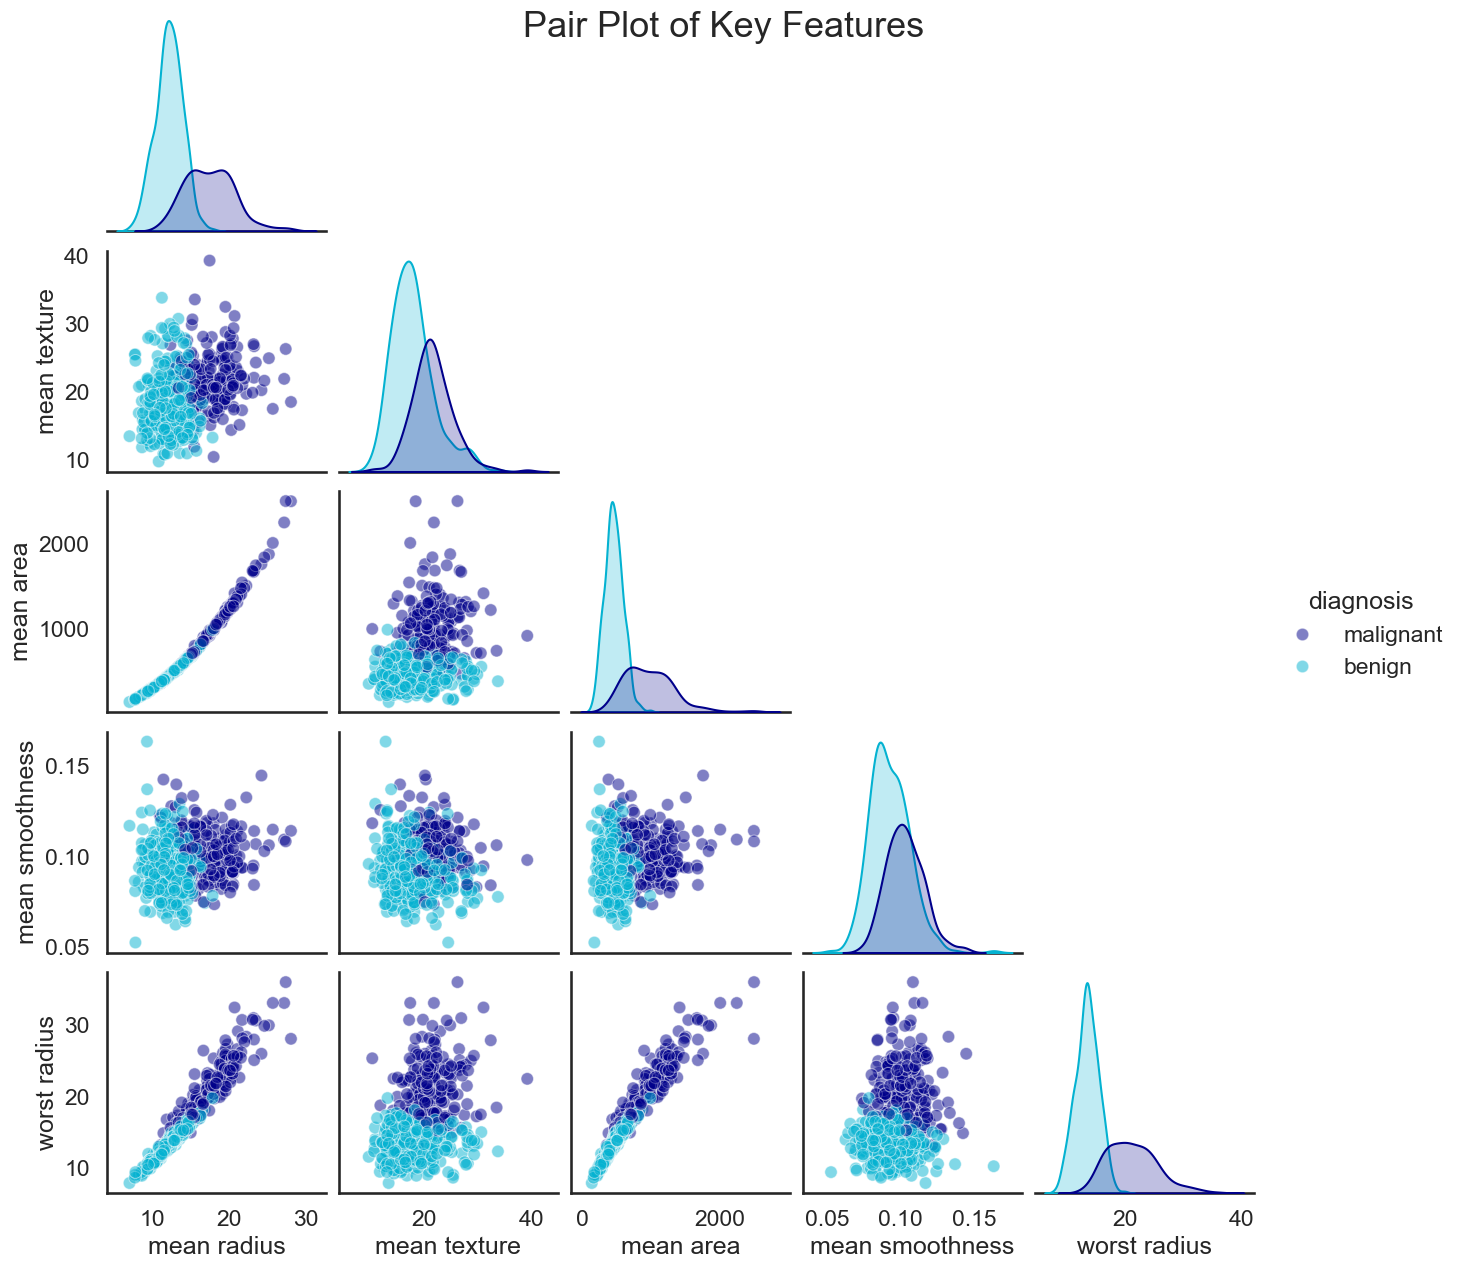

In [18]:
ft = ["mean radius", "mean texture", "mean area", "mean smoothness", "worst radius"]
vis.plot_pairplot(df, ft, palette=cols)

#### Observations:
Several feature pairs exhibit clear class separation, suggesting that linear or low-dimensional decision boundaries may perform well.

## 5. Global Feature Structure (PCA)
We explored dimensionality further by conducting a Principle Components Analysis (PCA), limiting it to two components.

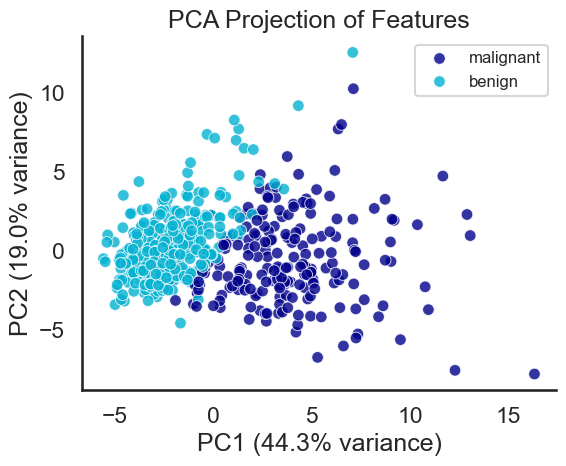

In [19]:
vis.plot_pca(df, palette=cols)

#### Observations:
- the classes are easily separable when mapping the first and second components
- the first two components explain nearly 65% of the variance, indicating that there is substantial overlap in feature space

Projection onto the first two principle components reveals a strong separation between malignant and benign samples, indicating that the underlying feature space contains structure suitible for classification.

## 6. Preliminary Feature Importance
As an exploratory step, we ran a random forest classifier and logistic regression to see which features contribute most to model performance. Feature importance analysis highlights several variables that strongly contribute to classification performance, guiding model interpretation and potential dimensionality reduction.

### 6.1 Random Forest
Random forest captures complex non-linear patterns in data and can find correlations between features. Feature importance scores tell us which cell morphology measurements are most predictive. This is valuable for clinical interpretation. We will only run a baseline model, no tuning.

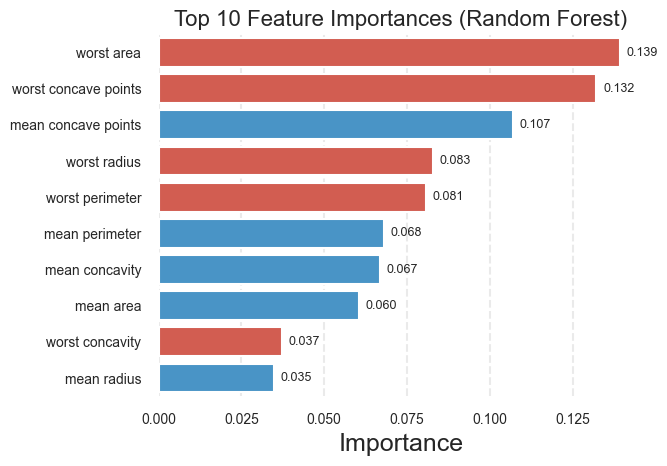

In [20]:
vis.plot_rf_feature_importance(df, measures=measures, measures_cols=measures_cols)

#### Observations:
The `worst` measurements dominate predictive power

### 6.2 Logistic Regression
Logistic regression captures linear relationships between variables, and coefficient magnitudes represent the amount each feature contributes to the model performance. As previously mentioned, we must take differences in scales into consideration prior to running the logistic regression. We will only run a baseline model, no regularization.

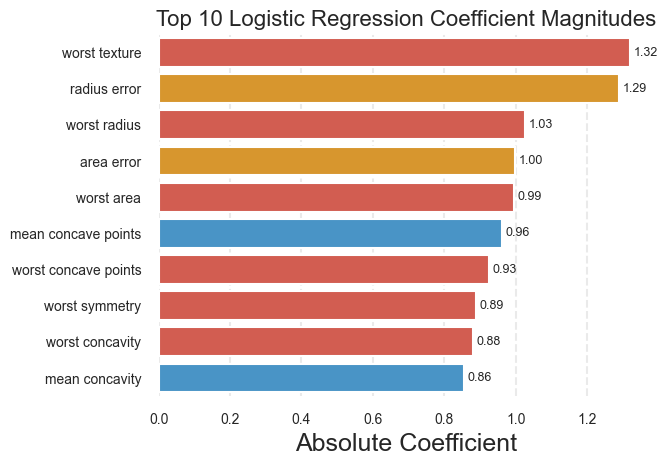

In [21]:
vis.plot_lf_coef_magnitude(df, measures=measures, measures_cols=measures_cols)

#### Observations:
Several features, particularly worst concave points and worst radius, appear among the most influential predictors across both models, suggesting strong and consistent associations with tumor malignancy.

# 7. Proposed Modelling Plan
### 7.1 Potential Risks Revealed by EDA
- Strong multicollinearity suggests regularization is necessary
- Scaling is required for linear models
- Redundant predictors motivate dimensionality reduction or shrinkage
- Small sample size increases risk of coefficient instability
- ROC-AUC is preferred over accuracy due to mild class imbalance
- train/test split with stratification due to mild class imbalance

### 7.2 Models
**Linear Models (Logistic Regression)**:
- no regularization (baseline)
- L1 regularization (Lasso)
- L2 regularization (Ridge)

**Advanced Models**:
- Random forest (baseline)
- Random forest (tuned)
- Support vector machine

### 7.3 Model Evaluation
- Accuracy
- Sensitivity
- Specificity
- AUC-ROC
- False Negatives
- False Positives

### 7.4 Model Comparisons 
- logistic unregularized vs L1 vs L2 
    <!-- - shows effect of multicollinearity, shrinkage, feature selection -->
- logistic vs RF vs SVM
    <!-- - interpretability vs performance tradeoff -->

### 7.5 Interpretability & Stability
- multicollinearity 
- coefficient magnitude
- feature importance
- decision curves


<!-- 
## EDA

## Logistic

## Advanced

## Evaluation & Selection

## Interpretation (Report) 
-->


--- 

Author: SE Creighton

_Last Updated: 2026-03-06_